# Detecting COVID-19 with Chest X Ray using PyTorch

Image classification of Chest X Rays in one of three classes: Normal, Viral Pneumonia, COVID-19

Dataset from [COVID-19 Radiography Dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database) on Kaggle

# Importing Libraries

In [1]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Objectif : charger tous les outils nécessaires
os, shutil : gestion des dossiers et fichiers
random : sélection aléatoire des images
torch, torchvision : deep learning avec PyTorch
PIL : lecture des images
matplotlib : visualisation
numpy : calcul numérique
torch.manual_seed(0)
Garantit la reproductibilité des résultats.

In [2]:
%matplotlib inline

import os
import shutil
import random
import torch
import torchvision
import numpy as np

from PIL import Image
from matplotlib import pyplot as plt

torch.manual_seed(0)

print('Using PyTorch version', torch.__version__)

Using PyTorch version 2.9.1+cpu


# Preparing Training and Test Sets

In [3]:
class_names = ['normal', 'viral', 'covid']
root_dir = '/COVID-19_Radiography_Dataset/'
source_dirs = ['NORMAL', 'Viral Pneumonia', 'COVID-19']

if os.path.isdir(os.path.join(root_dir, source_dirs[1])):
    os.mkdir(os.path.join(root_dir, 'test'))

    for i, d in enumerate(source_dirs):
        os.rename(os.path.join(root_dir, d), os.path.join(root_dir, class_names[i]))

    for c in class_names:
        os.mkdir(os.path.join(root_dir, 'test', c))

    for c in class_names:
        images = [x for x in os.listdir(os.path.join(root_dir, c)) if x.lower().endswith('png')]
        selected_images = random.sample(images, 30)
        for image in selected_images:
            source_path = os.path.join(root_dir, c, image)
            target_path = os.path.join(root_dir, 'test', c, image)
            shutil.move(source_path, target_path)

# Preparing Training and Test Sets

In [ ]:
#Réorganisation automatique
Renommage des dossiers
Création d’un dossier test/
Déplacement de 30 images par classe vers le test set
Cela permet de #séparer les données d’entraînement et de test,

In [4]:
class ChestXRayDataset(torch.utils.data.Dataset):
    def __init__(self, image_dirs, transform):
        def get_images(class_name):
            images = [x for x in os.listdir(image_dirs[class_name]) if x.lower().endswith('png')]
            print(f'Found {len(images)} {class_name} examples')
            return images

        self.images = {}
        self.class_names = ['normal', 'viral', 'covid']

        for c in self.class_names:
            self.images[c] = get_images(c)

        # These should be set once (not inside the loop)
        self.image_dirs = image_dirs
        self.transform = transform

    def __len__(self):
        return sum([len(self.images[c]) for c in self.class_names])

    def __getitem__(self, index):
        # Randomly choose a class (matches your original behavior)
        class_name = random.choice(self.class_names)

        # Keep index within the bounds of the selected class
        index = index % len(self.images[class_name])

        image_name = self.images[class_name][index]
        image_path = os.path.join(self.image_dirs[class_name], image_name)

        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, self.class_names.index(class_name)


In [ ]:
Fonctions clés :
#__init__
Charge les chemins des images
Affiche le nombre d’images par classe
#__len__
return sum([len(self.images[c]) for c in self.class_names])
Taille totale du dataset
#__getitem__
Sélectionne une image
Ouvre l’image en RGB
Aplique les transformations
Retourne : (image, label)

# Image Transformations

In [5]:
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(224, 224)),
    torchvision.transforms.RandomHorizontalFlip() ,
    torchvision.transforms.ToTensor() ,
    torchvision.transforms.Normalize(mean=[0.48, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
])


In [6]:
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(size=(224, 224)),
    torchvision.transforms.ToTensor() ,
    torchvision.transforms.Normalize(mean=[0.48, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225])
])


In [ ]:
#Test
Pas de flip (pas de modification aléatoire)

# Prepare DataLoader

In [7]:
train_dirs = {
    'normal': 'COVID-19_Radiography_Dataset/normal/images',
    'viral': 'COVID-19_Radiography_Dataset/viral/images',
    'covid': 'COVID-19_Radiography_Dataset/covid/images'
}

train_dataset = ChestXRayDataset(train_dirs, train_transform)

Found 10192 normal examples
Found 1345 viral examples
Found 3616 covid examples


In [8]:
test_dirs = {
    'normal': 'COVID-19_Radiography_Dataset/test/normal',
    'viral': 'COVID-19_Radiography_Dataset/test/viral',
    'covid': 'COVID-19_Radiography_Dataset/test/covid'
}
test_dataset = ChestXRayDataset(test_dirs, test_transform)


Found 30 normal examples
Found 30 viral examples
Found 30 covid examples


In [9]:
batch_size = 6
dl_train = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                shuffle=True)
dl_test = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                shuffle=True)
print('Num of training batches', len(dl_train))
print('Num of test batches', len(dl_test))

Num of training batches 2526
Num of test batches 15


# Data Visualization

In [10]:

class_names = train_dataset.class_names

def show_images(images, labels, preds):
    plt.figure(figsize=(12, 6))  # Correct syntax
    for i in range(min(len(images), 6)):  # Show up to 6 images
        plt.subplot(1, 6, i + 1, xticks=[], yticks=[])
        image = images[i].numpy().transpose((1, 2, 0))  # Corrected typo
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = image * std + mean
        image = np.clip(image, 0., 1.)
        plt.imshow(image)

        col = 'green' if preds[i] == labels[i] else 'red'
        plt.xlabel(class_names[int(labels[i].numpy())])
        plt.ylabel(class_names[int(preds[i].numpy())], color=col)

    plt.tight_layout()
    plt.show()



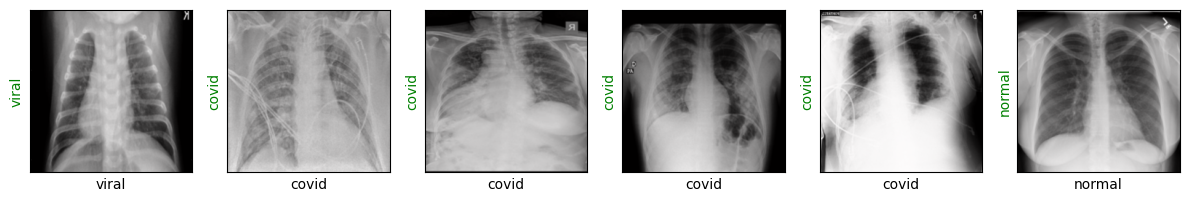

In [11]:

images, labels = next(iter(dl_train))
show_images(images, labels, labels)


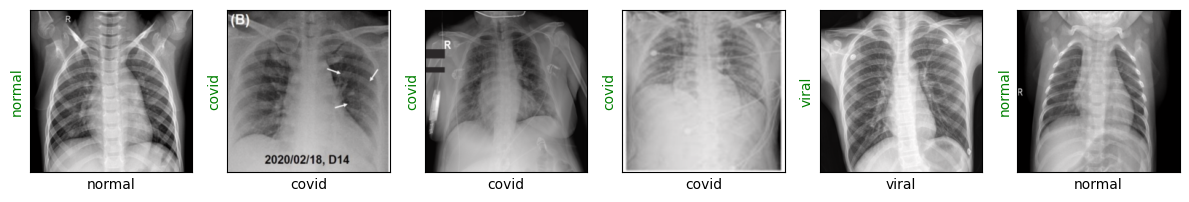

In [12]:

images, labels = next(iter(dl_test))
show_images(images, labels, labels)


# Creating the Model

In [14]:
resnet18 = torchvision.models.resnet18(pretrained=True)
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
import torch.nn as nn

num_features = resnet18.fc.in_features
resnet18.fc = nn.Sequential(
    nn.Dropout(p=0.2),          # 20% des neurones désactivés pendant l'entraînement
    nn.Linear(num_features, 3)   # couche finale qui produit les 3 classes
)



loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet18.parameters(), lr=3e-5)

In [ ]:
#Fonction de perte et optimiseur
CrossEntropyLoss → classification multi-classes
Adam → optimisation rapide et stable

In [16]:
def show_preds():
    resnet18.eval()
    images, labels =next(iter(dl_test))
    outputs = resnet18(images)
    _, preds = torch.max(outputs, 1)
    show_images(images, labels, preds)

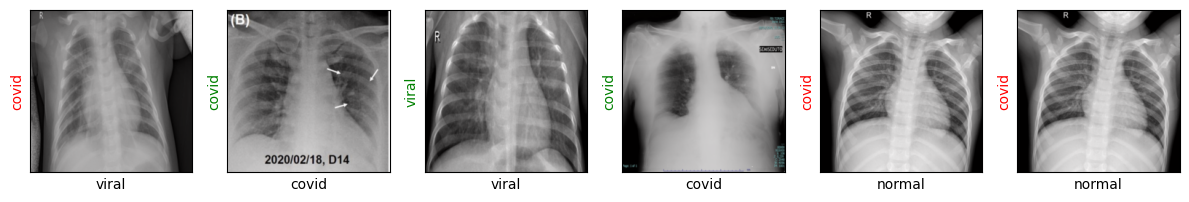

In [17]:
show_preds()

# Training the Model

In [ ]:
Étapes :
1.Passage en mode entraînement
2.Calcul des prédictions
3.Calcul de la perte
4.Backpropagation
5.Mise à jour des poids
6.Évaluation sur le test set

Critère d’arrêt :
if acc > 0.95:
return
Arrêt anticipé si précision > 95 %

In [18]:

def train(epochs):
    print('Starting training..')
    for e in range(epochs):
        print('=' * 20)
        print(f'Starting {e + 1}/{epochs}')
        print('=' * 20)

        train_loss = 0.0
        resnet18.train()

        for train_step, (images, labels) in enumerate(dl_train):
            optimizer.zero_grad()
            outputs = resnet18(images)
            loss = loss_fn(outputs, labels)  # Ajouté : définir la loss avant backward
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            if train_step % 20 == 0:
                print('Evaluating at step', train_step)
                acc = 0.0
                val_loss = 0.0
                resnet18.eval()

                with torch.no_grad():
                    for val_step, (images, labels) in enumerate(dl_test):
                        outputs = resnet18(images)
                        loss = loss_fn(outputs, labels)
                        val_loss += loss.item()

                        _, preds = torch.max(outputs, 1)
                        acc += (preds == labels).sum().item()

                val_loss /= (val_step + 1)
                acc = acc / len(test_dataset)
                print(f'Val loss: {val_loss:.4f}, Acc: {acc:.4f}')

                show_preds() 
            

                resnet18.train()

                if acc > 0.95:
                    print('Performance condition satisfied..')
                    return

        train_loss /= (train_step + 1)
        print(f'Training loss: {train_loss:.4f}')


Starting training..
Starting 1/1
Evaluating at step 0
Val loss: 1.1835, Acc: 0.4222


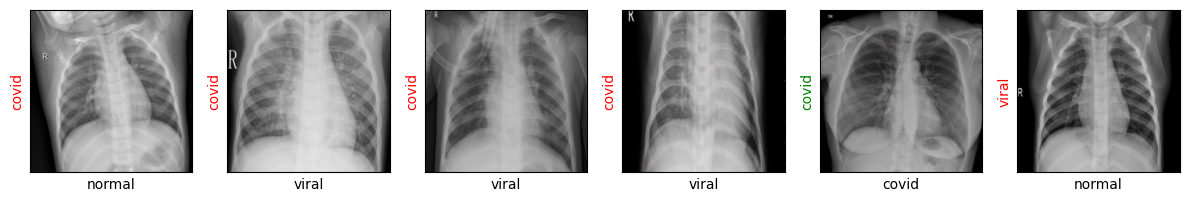

Evaluating at step 20
Val loss: 1.0124, Acc: 0.5333


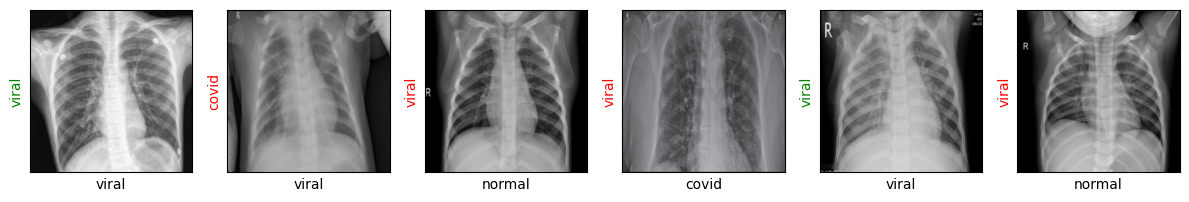

Evaluating at step 40
Val loss: 0.9422, Acc: 0.6000


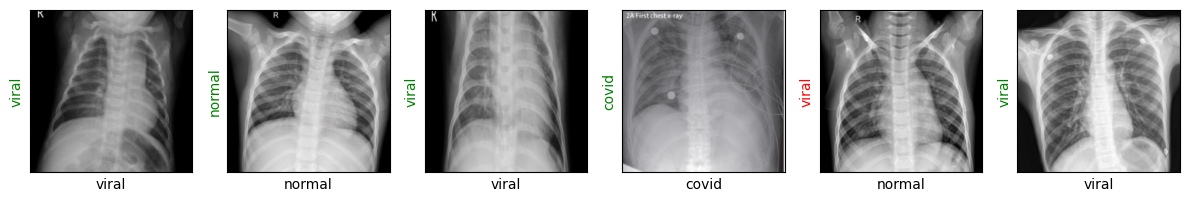

Evaluating at step 60
Val loss: 0.4696, Acc: 0.8667


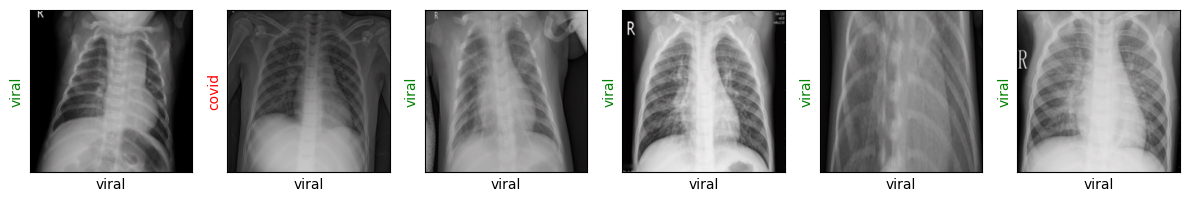

Evaluating at step 80
Val loss: 0.3122, Acc: 0.8778


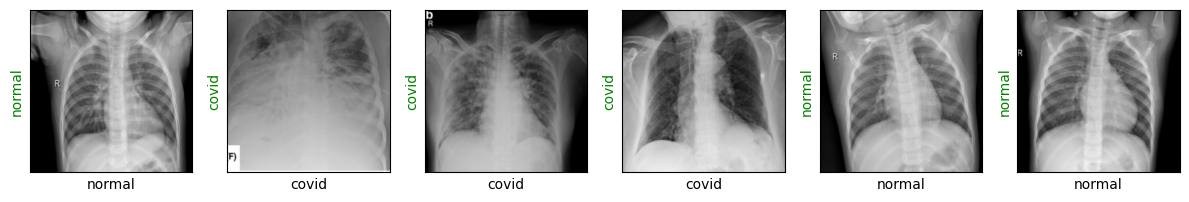

Evaluating at step 100
Val loss: 0.3283, Acc: 0.8667


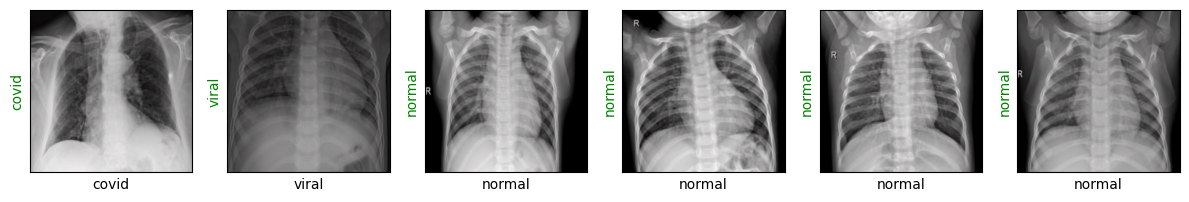

Evaluating at step 120
Val loss: 0.1960, Acc: 0.9556


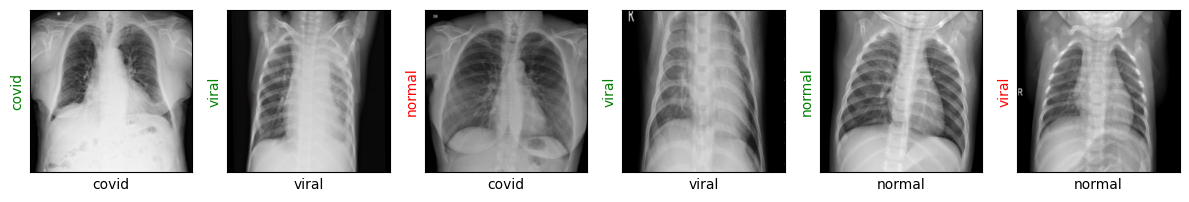

Performance condition satisfied..


In [19]:
train(epochs=1)

# Final Results

In [ ]:
Bonne convergence du modèle 
Précision satisfaisante 
Confusion possible 
      Pneumonie / COVID-19

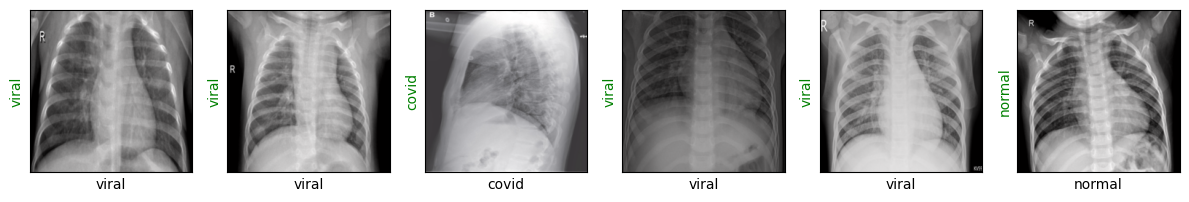

In [20]:
show_preds()

In [21]:

import torch
from torchvision import models
import torch.nn as nn

# 1) Reconstruire l'architecture EXACTE de l'entraînement
model = models.resnet18(weights=None)  # à l'inférence/sauvegarde, on peut laisser None
model.fc = nn.Linear(model.fc.in_features, 3)

# 2) (Optionnel) Charger des poids existants si tu veux re-sauvegarder proprement
# state = torch.load(r"C:\chemin\vers\poids_existants.pth", map_location="cpu")
# model.load_state_dict(state)

# 3) Sauvegarder
torch.save(model.state_dict(), "model.pth")
print("✅ Modèle sauvegardé avec succès sous le nom model.pth")


✅ Modèle sauvegardé avec succès sous le nom model.pth
